# Consideration Set Mixed Logit: Separating Attention from Preference

This notebook demonstrates a two-stage discrete choice model that separates *which alternatives get considered* from *which is preferred*. We apply it to the Swiss Metro stated-preference dataset (Train, SwissMetro, Car), compare a vanilla model with one that adds random effects on travel time, and show that the consideration-stage estimates can change dramatically when the utility stage is better specified.

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from pymc_marketing.customer_choice.consideration_set_logit import (
    ConsiderationSetMixedLogit,
)
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

SEED = 42
rng = np.random.default_rng(SEED)

## Motivation: Why Separate Consideration from Preference?

Standard discrete choice models assume every alternative is actively considered. The chosen option maximises utility across the full set. This is the rational-agent ideal, not how people decide.

Real decisions have two stages. First, *screening*: habits, awareness, and contextual cues determine which options enter the consideration set. Second, *evaluation*: among the considered options, the individual weighs trade-offs and picks the best. The old parable applies. The drunk searches for his keys under the streetlamp, not because he dropped them there, but because that's where the light is. People can only choose from what they notice.

A commuter who has never heard of SwissMetro cannot prefer it. A traveller without a rail pass may never think of the train, even when it dominates on time and cost. The consideration set bounds the search space before evaluation begins.

By conflating these stages, a standard logit attributes low market share to *low preference* when the real cause may be *low consideration*. The confusion matters. If rail's problem is consideration (people don't know about it), the remedy is marketing or subscriptions, not fare cuts. A standard logit prescribes the wrong intervention.

More broadly, when consideration determinants drive choices more strongly than utility parameters, it reveals that decisions are being made from a narrow menu. That is a signal about choice architecture: the question becomes whether to widen the set of options people actively evaluate. This is the difference between a marketing problem (not noticed) and a product problem (noticed but disliked).

## Mathematical Formulation

### Stage 1: Consideration

Each alternative $j$ has a consideration probability for individual $n$, driven by $K_z$ instruments:

$$\pi_{nj} = sigmoid\!\left(\sum_{k=1}^{K_z} \gamma_{zjk} \cdot \tilde{z}_{nk}\right)$$

Here $\gamma_{zjk}$ is the mode-specific sensitivity to instrument $k$ and $\tilde{z}_{nk}$ is mean-centred. In our application, $\gamma_z$ has shape (modes × instruments), so the same person-level trait can screen differently for different modes.

The instruments must satisfy an **exclusion restriction**: they affect *whether you notice* a mode but not *how you value it conditional on noticing*. Without this, the two stages are not separately identified.

The model optionally supports consideration intercepts $\gamma_{0j}$ and a random intercept $\eta_n \sim \mathcal{N}(0, \sigma_\eta^2)$ for individual-level attentiveness. We use neither in this notebook.

### Stage 2: Conditional Utility

$$V_{nj} = \alpha_j + \boldsymbol{\beta}_n' \mathbf{x}_{nj}$$

where $\boldsymbol{\beta}_n \sim \mathcal{N}(\boldsymbol{\mu}_\beta, \boldsymbol{\Sigma}_\beta)$ for random coefficients, or $\boldsymbol{\beta}_n = \boldsymbol{\beta}$ when fixed.

### Bridging the Two Stages

The choice probability combines consideration and utility via the **bridge formula**:

$$P(y_n = j \mid \boldsymbol{\beta}_n) = \text{softmax}_j\bigl(\log \pi_{nj} + V_{nj}\bigr)$$

The $\log \pi_{nj}$ term is a soft availability mask. As $\pi_{nj} \to 0$, the alternative is effectively removed from the choice set. When $\pi_{nj} = 1$ for all alternatives, the model reduces to a standard mixed logit.

For random coefficients, MCMC handles the marginal integral automatically. Each posterior draw of $\boldsymbol{\beta}_n$ is one sample from the mixing distribution; the posterior predictive averages over draws.

## Parameter Recovery: Simulated Hiring Data

Before applying the model to real data, we verify that it can recover known parameters. We simulate a hiring setting where three firms compete for candidates. The consideration stage is driven by two instruments: whether the candidate has a **graduate degree** and whether they are **white**. These instruments affect which firms *look at* a candidate (screening) but do not affect the candidate's quality conditional on being evaluated.

The utility stage depends on alternative-specific covariates: each firm offers different role characteristics (age of the team, years of experience required) that vary independently across firms. This variation identifies the utility parameters, since the covariates differ across alternatives within each choice scenario.

The exclusion restriction holds by construction. The model should recover the true `gamma_z` (screening slopes) and `beta` (utility weights) separately.

In [3]:
# ---- True parameters ----
TRUE_ALPHA = np.array([0.5, 1.0, 0.0])  # firm intercepts (Firm C = reference)
TRUE_B_AGE = -0.8  # older candidates less preferred
TRUE_B_EXP = 0.5  # more experience preferred
# Consideration slopes: (3 firms) x (2 instruments: grad_degree, white)
TRUE_GAMMA = np.array(
    [
        [1.5, 2.0],  # Firm A: screens on both
        [2.5, 0.5],  # Firm B: screens heavily on grad, weakly on race
        [0.5, 3.0],  # Firm C: screens heavily on race, weakly on grad
    ]
)

# ---- Simulate data ----
n_sim = 400
np.random.seed(SEED)

# Consideration instruments (screening-relevant only)
grad_degree = np.random.binomial(1, 0.35, n_sim).astype(float)
white = np.random.binomial(1, 0.65, n_sim).astype(float)
Z_person_sim = np.column_stack([grad_degree, white])
Z_means_sim = Z_person_sim.mean(axis=0)
Z_tilde_sim = Z_person_sim - Z_means_sim

# Stack to (N, J=3, K_z=2)
Z_tilde_3d_sim = np.stack([Z_tilde_sim] * 3, axis=1)

# Generate choices from the true model
# Each firm offers different conditions (alternative-specific covariates)
rows_sim = []
for i in range(n_sim):
    # Consideration probabilities
    log_odds = TRUE_GAMMA @ Z_tilde_sim[i]  # (3,)
    pi = 1.0 / (1.0 + np.exp(-log_odds))

    # Alternative-specific covariates: each firm has different age/exp profiles
    # (e.g., role seniority, expected workload differ across firms)
    age_A = np.random.uniform(22, 60) / 40
    age_B = np.random.uniform(22, 60) / 40
    age_C = np.random.uniform(22, 60) / 40
    exp_A = np.random.uniform(0, 30) / 20
    exp_B = np.random.uniform(0, 30) / 20
    exp_C = np.random.uniform(0, 30) / 20

    # Utility — covariates now vary across alternatives
    V = np.array(
        [
            TRUE_ALPHA[0] + TRUE_B_AGE * age_A + TRUE_B_EXP * exp_A,
            TRUE_ALPHA[1] + TRUE_B_AGE * age_B + TRUE_B_EXP * exp_B,
            TRUE_ALPHA[2] + TRUE_B_AGE * age_C + TRUE_B_EXP * exp_C,
        ]
    )

    # Bridge formula
    U_adj = np.log(pi + 1e-12) + V
    U_adj -= U_adj.max()
    p = np.exp(U_adj) / np.exp(U_adj).sum()
    choice = np.random.choice(["Firm A", "Firm B", "Firm C"], p=p)

    rows_sim.append(
        {
            "choice": choice,
            "age_A": age_A,
            "age_B": age_B,
            "age_C": age_C,
            "exp_A": exp_A,
            "exp_B": exp_B,
            "exp_C": exp_C,
        }
    )

df_sim = pd.DataFrame(rows_sim)
print(f"Simulated {n_sim} hiring decisions")
print(df_sim["choice"].value_counts().sort_index())

Simulated 400 hiring decisions
choice
Firm A    117
Firm B    205
Firm C     78
Name: count, dtype: int64


In [4]:
# ---- Fit the consideration set model ----
sim_equations = [
    "Firm A ~ age_A + exp_A",
    "Firm B ~ age_B + exp_B",
    "Firm C ~ age_C + exp_C",
]

model_sim = ConsiderationSetMixedLogit(
    choice_df=df_sim,
    utility_equations=sim_equations,
    depvar="choice",
    covariates=["age", "exp"],
    consideration_instruments={
        "Z_tilde": Z_tilde_3d_sim,
        "z_instrument_names": ["Grad_degree", "White"],
    },
    consideration_intercept=False,
    random_consideration=False,
)

idata_sim = model_sim.fit(
    random_seed=SEED,
    fit_kwargs={
        "draws": 1000,
        "tune": 1000,
        "chains": 4,
        "target_accept": 0.95,
    },
)

print("Simulation recovery model fitted.")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Simulation recovery model fitted.


/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/2579984878.py:99: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


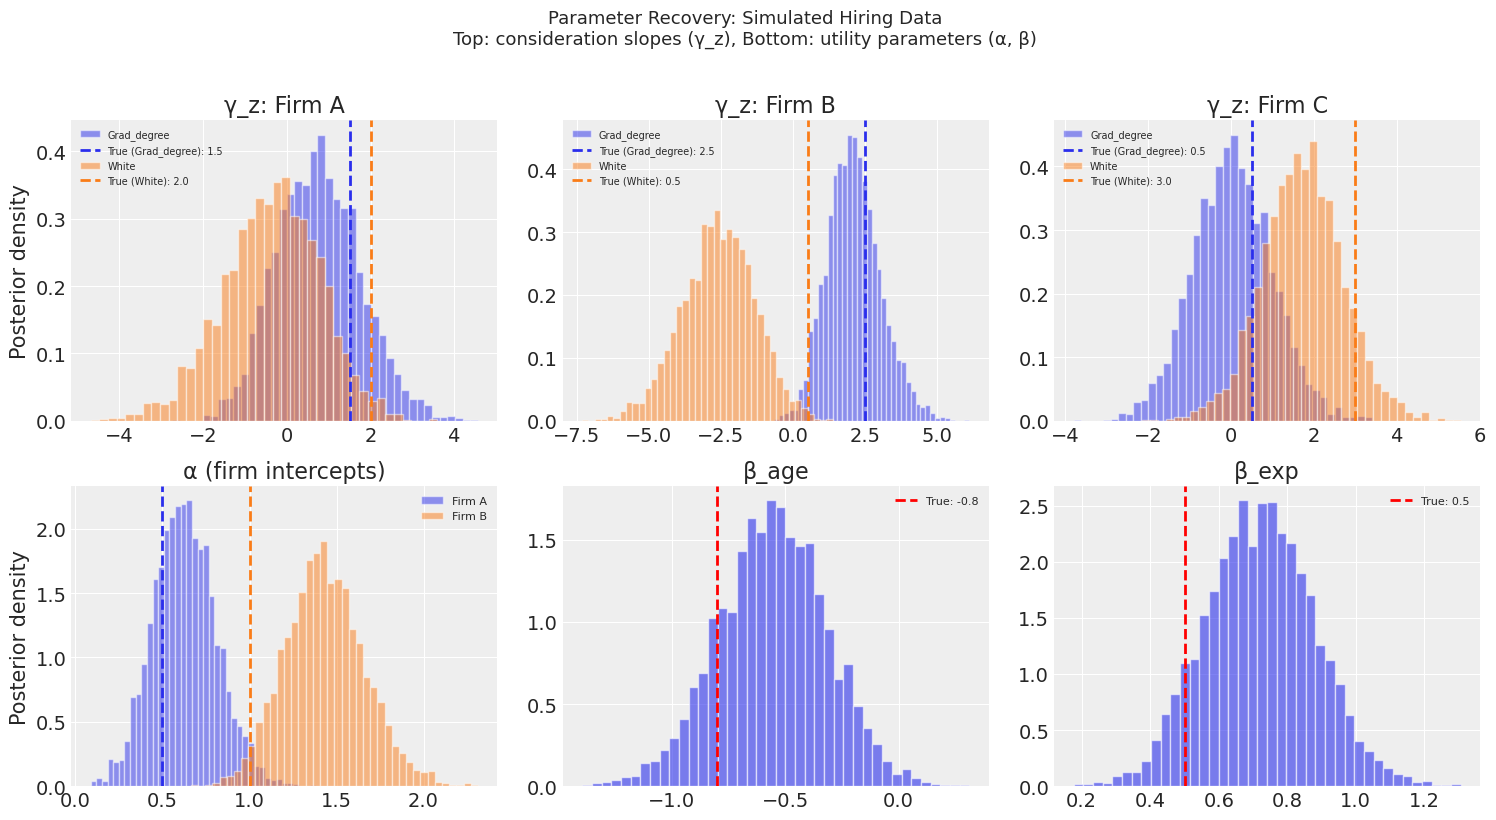

In [5]:
# ---- Parameter recovery plot ----
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top row: gamma_z recovery (consideration slopes)
firm_names = ["Firm A", "Firm B", "Firm C"]
z_inst_names = ["Grad_degree", "White"]
for j, firm in enumerate(firm_names):
    ax = axes[0, j]
    gamma_post = idata_sim.posterior["gamma_z"].sel(alts=firm)
    for k, inst in enumerate(z_inst_names):
        samples = gamma_post.sel(z_instruments=inst).values.flatten()
        ax.hist(
            samples,
            bins=40,
            alpha=0.5,
            density=True,
            label=inst,
            color=f"C{k}",
            edgecolor="white",
        )
        ax.axvline(
            TRUE_GAMMA[j, k],
            color=f"C{k}",
            linestyle="--",
            linewidth=2,
            label=f"True ({inst}): {TRUE_GAMMA[j, k]:.1f}",
        )
    ax.set_title(f"γ_z: {firm}")
    ax.legend(fontsize=7)
    if j == 0:
        ax.set_ylabel("Posterior density")

# Bottom row: utility parameter recovery
# Alphas (intercepts)
ax_alpha = axes[1, 0]
for j, firm in enumerate(firm_names[:2]):  # Firm C is reference (alpha=0)
    samples = idata_sim.posterior["alphas_"].sel(alts=firm).values.flatten()
    ax_alpha.hist(
        samples,
        bins=40,
        alpha=0.5,
        density=True,
        label=firm,
        color=f"C{j}",
        edgecolor="white",
    )
    ax_alpha.axvline(
        TRUE_ALPHA[j],
        color=f"C{j}",
        linestyle="--",
        linewidth=2,
    )
ax_alpha.set_title("α (firm intercepts)")
ax_alpha.legend(fontsize=8)
ax_alpha.set_ylabel("Posterior density")

# Beta_age — dim is "normal_covariates", labels are covariate names
ax_age = axes[1, 1]
samples_age = (
    idata_sim.posterior["betas_non_random"]
    .sel(normal_covariates="age")
    .values.flatten()
)
ax_age.hist(samples_age, bins=40, alpha=0.6, density=True, edgecolor="white")
ax_age.axvline(
    TRUE_B_AGE,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"True: {TRUE_B_AGE}",
)
ax_age.set_title("β_age")
ax_age.legend(fontsize=8)

# Beta_exp
ax_exp = axes[1, 2]
samples_exp = (
    idata_sim.posterior["betas_non_random"]
    .sel(normal_covariates="exp")
    .values.flatten()
)
ax_exp.hist(samples_exp, bins=40, alpha=0.6, density=True, edgecolor="white")
ax_exp.axvline(
    TRUE_B_EXP,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"True: {TRUE_B_EXP}",
)
ax_exp.set_title("β_exp")
ax_exp.legend(fontsize=8)

plt.suptitle(
    "Parameter Recovery: Simulated Hiring Data\n"
    "Top: consideration slopes (γ_z), Bottom: utility parameters (α, β)",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

The model recovers both stages. The dashed lines (true values) fall within the posterior mass for all parameters. The consideration slopes are cleanly separated from the utility weights because the exclusion restriction holds by construction: graduate degree and race affect screening, while age and experience affect evaluation.

Now consider the counterfactual that motivated the hiring example. What happens if we blind the screening stage to race? We set the "White" instrument to zero for all candidates, leaving graduate degree screening intact. This is the analogue of anonymising CVs.

In [6]:
# ---- Counterfactual: blind screening to race ----
# Baseline: posterior predictive with original instruments
model_sim.sample_posterior_predictive(random_seed=SEED)

# Counterfactual: set White instrument to 0 (mean-centred, so 0 = population average)
Z_tilde_blind = Z_tilde_3d_sim.copy()
Z_tilde_blind[:, :, 1] = 0.0  # remove race signal

idata_blind = model_sim.apply_intervention(
    new_choice_df=df_sim,
    new_consideration_instruments={
        "Z_tilde": Z_tilde_blind,
        "z_instrument_names": ["Grad_degree", "White"],
    },
)

# Compare market shares
p_base = model_sim.idata.posterior_predictive["p"].mean(dim=["chain", "draw"]).values
p_blind = idata_blind.posterior_predictive["p"].mean(dim=["chain", "draw"]).values

share_base = p_base.mean(axis=0)
share_blind = p_blind.mean(axis=0)

sim_share_df = pd.DataFrame(
    {
        "Firm": firm_names,
        "Baseline Share": share_base,
        "Race-Blind Share": share_blind,
        "Change": share_blind - share_base,
        "% Change": 100 * (share_blind - share_base) / share_base,
    }
).round(4)

print("Counterfactual: Race-blind screening")
print("White instrument zeroed (= population mean consideration)")
sim_share_df

Sampling: [likelihood]


Output()

Sampling: [likelihood]


Output()

Counterfactual: Race-blind screening
White instrument zeroed (= population mean consideration)


,Firm,Baseline Share,Race-Blind Share,Change,% Change
0,Firm A,0.2923,0.2817,-0.0106,-3.6175
1,Firm B,0.5127,0.5528,0.0401,7.8182
2,Firm C,0.1950,0.1655,-0.0295,-15.1308


The shift in market shares reflects the *structure we built in*. Firm C, which screened most heavily on race (γ = 3.0), loses the most from blinding. Firm B, which screened mostly on graduate degree (γ = 2.5 vs 0.5), is barely affected. The counterfactual is credible here because the exclusion restriction is clean: race affects screening, not productivity. The model correctly decomposes the two channels.

This is the benchmark. When we turn to the Swiss Metro data below, the instruments are messier (GA proxies for lifestyle, not just awareness) and the exclusion restriction is debatable. The parameter recovery exercise establishes that the model works when its assumptions hold. The empirical application then asks what happens when they are strained.

---

## Loading and Exploring the Swiss Metro Data

The Swiss Metro dataset is a stated-preference survey. Respondents choose between Train, SwissMetro (a hypothetical high-speed rail), and Car across 9 choice scenarios with varying travel times, costs, headways, and seat configurations.

In [7]:
data_path = data_dir / "swissmetro.dat"
raw = pd.read_csv(data_path, sep="\t")

# Standard filter: stated preference observations with valid choices
df = raw[(raw["SP"] == 1) & (raw["CHOICE"] != 0)].copy()
print(f"Observations: {len(df):,}")
print(f"Unique individuals: {df['ID'].nunique():,}")
print(f"Observations per individual: {len(df) // df['ID'].nunique()}")
print("\nChoice distribution:")
choice_map = {1: "Train", 2: "SwissMetro", 3: "Car"}
print(df["CHOICE"].map(choice_map).value_counts().sort_index())
car_unavail = (df["CAR_AV"] == 0).sum()
car_pct = 100 * (df["CAR_AV"] == 0).mean()
print(f"\nCar unavailable in {car_unavail:,} / {len(df):,} obs ({car_pct:.1f}%)")

Observations: 10,719
Unique individuals: 1,191
Observations per individual: 9

Choice distribution:
CHOICE
Car           3080
SwissMetro    6216
Train         1423
Name: count, dtype: int64

Car unavailable in 1,683 / 10,719 obs (15.7%)


## Data Preprocessing

We prepare the data in wide format: string choice labels, scaled travel times and costs for numerical stability, and a subsample for tractable MCMC.

In [8]:
# Create string choice labels
df["choice"] = df["CHOICE"].map(choice_map)

# Scale covariates for numerical stability
df["train_tt"] = df["TRAIN_TT"] / 100  # travel time in units of 100 min
df["train_co"] = df["TRAIN_CO"] / 100  # cost in CHF
df["sm_tt"] = df["SM_TT"] / 100
df["sm_co"] = df["SM_CO"] / 100
df["car_tt"] = df["CAR_TT"] / 100
df["car_co"] = df["CAR_CO"] / 100

# Subsample for tractable notebook demonstration
# Take a random subset of individuals (preserving panel structure)
sampled_ids = rng.choice(df["ID"].unique(), size=250, replace=False)
df_sub = df[df["ID"].isin(sampled_ids)].copy().reset_index(drop=True)

print(
    f"Subsampled: {len(df_sub):,} observations from {df_sub['ID'].nunique()} individuals"
)
print("\nChoice distribution (subsample):")
print(df_sub["choice"].value_counts().sort_index())
df_sub[
    [
        "ID",
        "choice",
        "train_tt",
        "train_co",
        "sm_tt",
        "sm_co",
        "car_tt",
        "car_co",
        "TRAIN_HE",
        "SM_HE",
        "CAR_AV",
        "GA",
    ]
].head(6)

Subsampled: 2,250 observations from 250 individuals

Choice distribution (subsample):
choice
Car            655
SwissMetro    1255
Train          340
Name: count, dtype: int64


,ID,choice,train_tt,train_co,sm_tt,sm_co,car_tt,car_co,TRAIN_HE,SM_HE,CAR_AV,GA
0,8,SwissMetro,1.09,0.26,0.56,0.34,1.3,0.30,120,20,1,0
1,8,SwissMetro,1.00,0.26,0.53,0.32,1.3,0.39,30,10,1,0
2,8,SwissMetro,1.26,0.26,0.60,0.40,1.3,0.24,60,30,1,0
3,8,Car,1.00,0.22,0.56,0.35,0.8,0.24,30,20,1,0
4,8,SwissMetro,1.26,0.20,0.56,0.24,1.0,0.39,60,20,1,0
5,8,Car,1.09,0.20,0.53,0.32,1.0,0.24,120,10,1,0


## Constructing Consideration Instruments

The consideration instruments must satisfy the exclusion restriction: they should affect whether a mode enters the consideration set, not utility conditional on consideration. Without this separation, the model cannot distinguish "didn't notice" from "noticed but disliked."

We use four person-level characteristics. Each captures a reason why someone's streetlamp might point in a particular direction.

**GA (General Abonnement)** is an annual rail pass. Holders are habituated to rail. The pass doesn't change how fast or cheap a trip is; it changes whether rail is on the radar. A subscription buys you into a consideration set. **Business** indicates a business trip. Business travellers may default to employer-reimbursed modes or familiar routines, narrowing consideration before any evaluation of time or cost. **High income** flags household income above the median. Higher income may expand the consideration set: more modes feel affordable enough to think about. **Older** flags respondents above the median age, who may have entrenched habits that restrict active consideration.

The key feature is that `gamma_z` varies by mode. A GA pass may strongly increase Train consideration while having no effect on Car. The model learns these mode-specific sensitivities from the data.

In [9]:
# ---- Person-level consideration instruments ----
ga = df_sub["GA"].values.astype(float)
business = (df_sub["PURPOSE"] == 1).values.astype(float)
high_inc = (df_sub["INCOME"] > 2).values.astype(float)
older = (df_sub["AGE"] > 3).values.astype(float)

# Composite Z: same instruments for each mode, but gamma varies by mode
Z_person = np.column_stack([ga, business, high_inc, older])  # (N, 4)
Z_means = Z_person.mean(axis=0)
Z_tilde_person = Z_person - Z_means  # mean-centred

# Stack to (N, J, K_z) — same person-level Z for all modes
# gamma_z[j, k] will learn mode-specific sensitivities
n_alts = 3
Z_tilde = np.stack([Z_tilde_person] * n_alts, axis=1)  # (N, 3, 4)

z_names = ["GA", "Business", "High_income", "Older"]

print(f"Z_tilde shape: {Z_tilde.shape}  (N, J, K_z)")
print("\nInstrument means (pre-centring):")
for name, m in zip(z_names, Z_means, strict=True):
    print(f"  {name:12s}: {m:.3f}")
print(f"\nZ_tilde column means (should be ~0): {Z_tilde_person.mean(axis=0).round(6)}")

Z_tilde shape: (2250, 3, 4)  (N, J, K_z)

Instrument means (pre-centring):
  GA          : 0.156
  Business    : 0.160
  High_income : 0.432
  Older       : 0.224

Z_tilde column means (should be ~0): [-0.  0. -0.  0.]


/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/2256022244.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


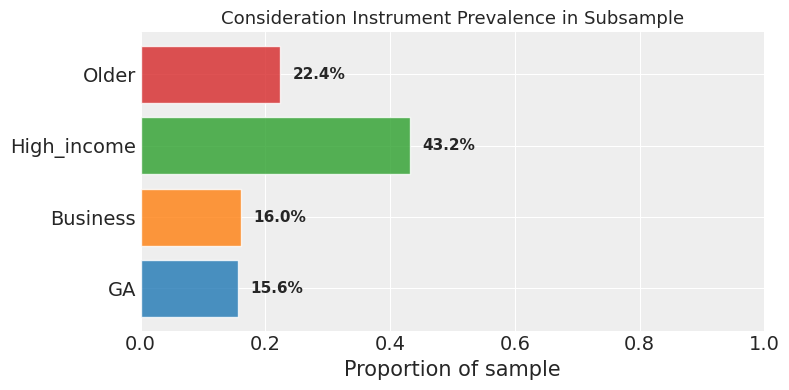

In [10]:
# Instrument prevalence (pre-centring) — proportion of sample with each trait
instrument_rates = Z_means
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
bars = ax.barh(z_names, instrument_rates, color=colors, alpha=0.8, edgecolor="white")
ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of sample")
ax.set_title("Consideration Instrument Prevalence in Subsample", fontsize=13)
for bar, rate in zip(bars, instrument_rates, strict=True):
    ax.text(
        rate + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1%}",
        va="center",
        fontsize=11,
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

## Model 1: Vanilla Consideration Set Logit (No Random Effects)

Our first model uses fixed coefficients for travel time and cost. This is the simplest consideration set model: a consideration stage on top of a standard conditional logit. Travel time and cost are alternative-specific covariates, varying across modes within each choice scenario.

In [11]:
# Utility equations: alternative ~ alt_specific_covariates
# No fixed (individual-level) covariates, no random covariates
utility_equations = [
    "Train ~ train_tt + train_co",
    "SwissMetro ~ sm_tt + sm_co",
    "Car ~ car_tt + car_co",
]

model_vanilla = ConsiderationSetMixedLogit(
    choice_df=df_sub,
    utility_equations=utility_equations,
    depvar="choice",
    covariates=["tt", "co"],
    consideration_instruments={
        "Z_tilde": Z_tilde,
        "z_instrument_names": z_names,
    },
    consideration_intercept=False,  # default: utility intercepts absorb baseline
    random_consideration=False,
    group_id="ID",
    sampler_config={
        "target_accept": 0.95,
        "tune": 1000,
        "draws": 1000,
        "chains": 4,
        "cores": 4,
        "nuts_sampler": "pymc",
    },
)

model_vanilla.build_model()
print("Model 1 (vanilla consideration) free RVs:")
print([v.name for v in model_vanilla.model.free_RVs])
print("\nDeterministics:")
print([v.name for v in model_vanilla.model.deterministics])

Model 1 (vanilla consideration) free RVs:
['alphas_', 'betas_non_random', 'gamma_z']

Deterministics:
['alphas', 'betas_individuals', 'U', 'pi', 'p']


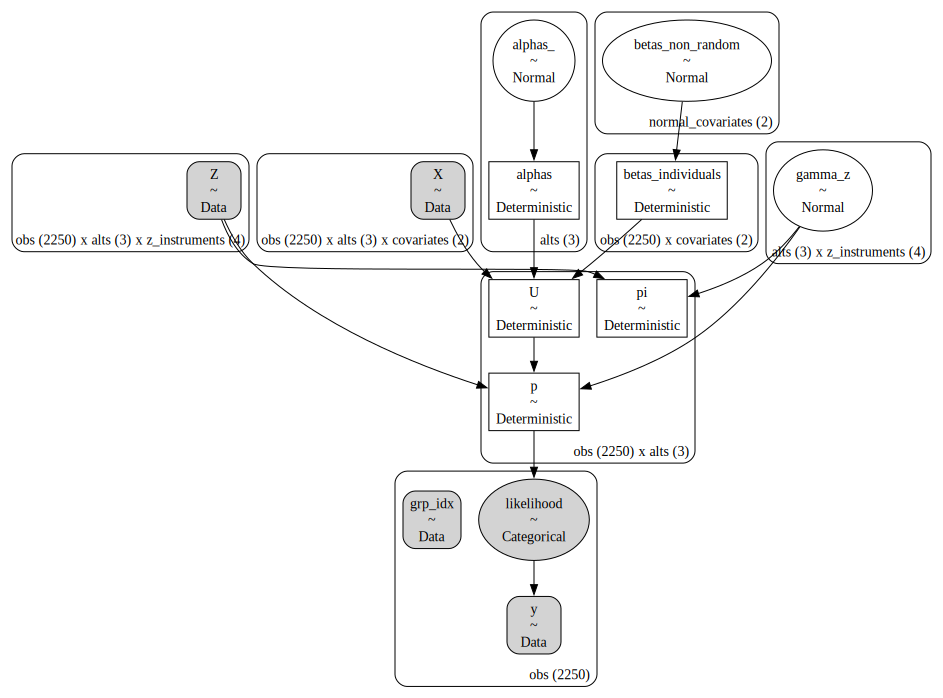

In [12]:
pm.model_to_graphviz(model_vanilla.model)

In [13]:
idata_vanilla = model_vanilla.fit(
    idata_kwargs={"log_likelihood": True},
    random_seed=SEED,
    fit_kwargs={
        "target_accept": 0.95,
        "tune": 1000,
        "draws": 1000,
        "chains": 4,
        "cores": 4,
    },
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alphas_, betas_non_random, gamma_z]
/Users/nathanielforde/mambaforge/envs/pymc-marketing-dev/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 85 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [14]:
var_names_vanilla = ["alphas_", "betas_non_random", "gamma_z"]
az.summary(idata_vanilla, var_names=var_names_vanilla, round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alphas_[Train],-0.792,0.124,-1.032,-0.564,0.005,0.002,646.965,2519.040,1.004
alphas_[SwissMetro],0.706,0.091,0.532,0.873,0.003,0.002,1197.576,2086.306,1.003
alphas_[Car],-0.147,5.116,-9.635,9.324,0.085,0.083,3623.412,2851.652,1.000
betas_non_random[tt],-0.398,0.063,-0.509,-0.271,0.001,0.001,2786.755,2485.086,1.003
betas_non_random[co],-0.071,0.014,-0.098,-0.046,0.000,0.000,1310.500,1978.245,1.001
"gamma_z[Train, GA]",-0.455,1.212,-2.618,1.901,0.063,0.026,359.877,1141.808,1.017
"gamma_z[Train, Business]",0.279,0.725,-1.003,1.611,0.026,0.014,802.307,1717.946,1.007
"gamma_z[Train, High_income]",0.595,1.300,-1.369,2.762,0.090,0.018,258.473,1938.670,1.022
"gamma_z[Train, Older]",-1.133,0.789,-2.409,0.286,0.048,0.009,285.440,1704.068,1.018
"gamma_z[SwissMetro, GA]",-2.346,0.780,-3.891,-0.981,0.032,0.013,605.028,1462.141,1.011


/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/3411361122.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


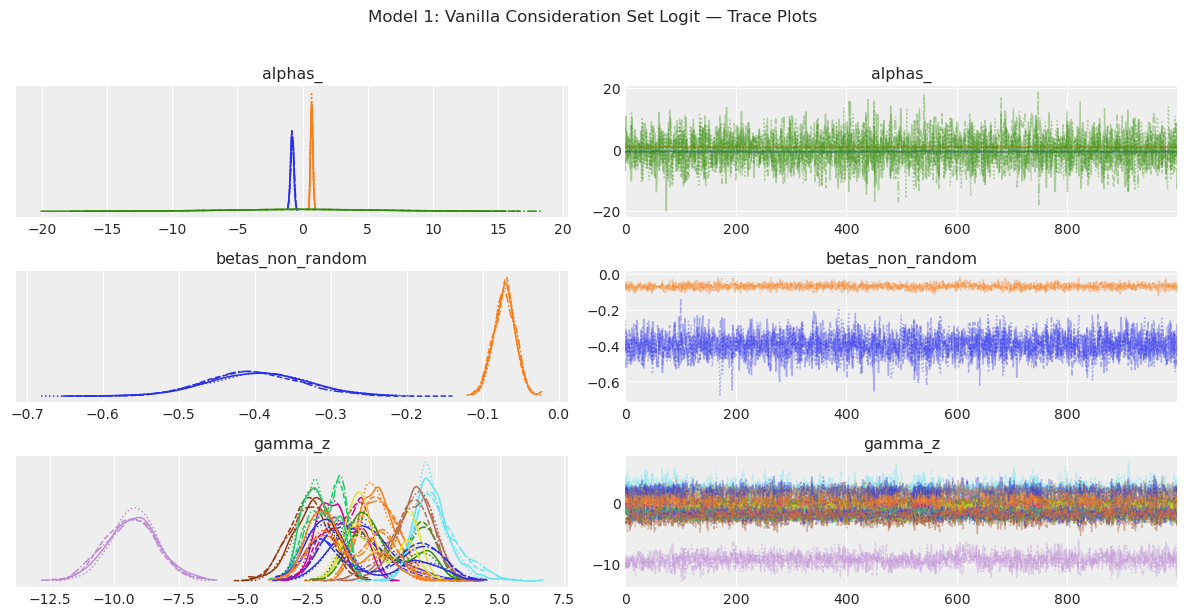

In [15]:
axes = az.plot_trace(idata_vanilla, var_names=var_names_vanilla, compact=True)
plt.suptitle("Model 1: Vanilla Consideration Set Logit — Trace Plots", y=1.02)
plt.tight_layout()
plt.show()

### Interpreting the Consideration Stage

The `gamma_z` parameters answer the question: *what determines where the streetlamp shines?* We have 4 instruments and 3 modes, giving 12 screening slopes. A positive `gamma_z` means the instrument increases consideration of that mode. Where these slopes are large relative to utility parameters, consideration is the primary driver of choice. That is the audit signal.

/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/4072542000.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


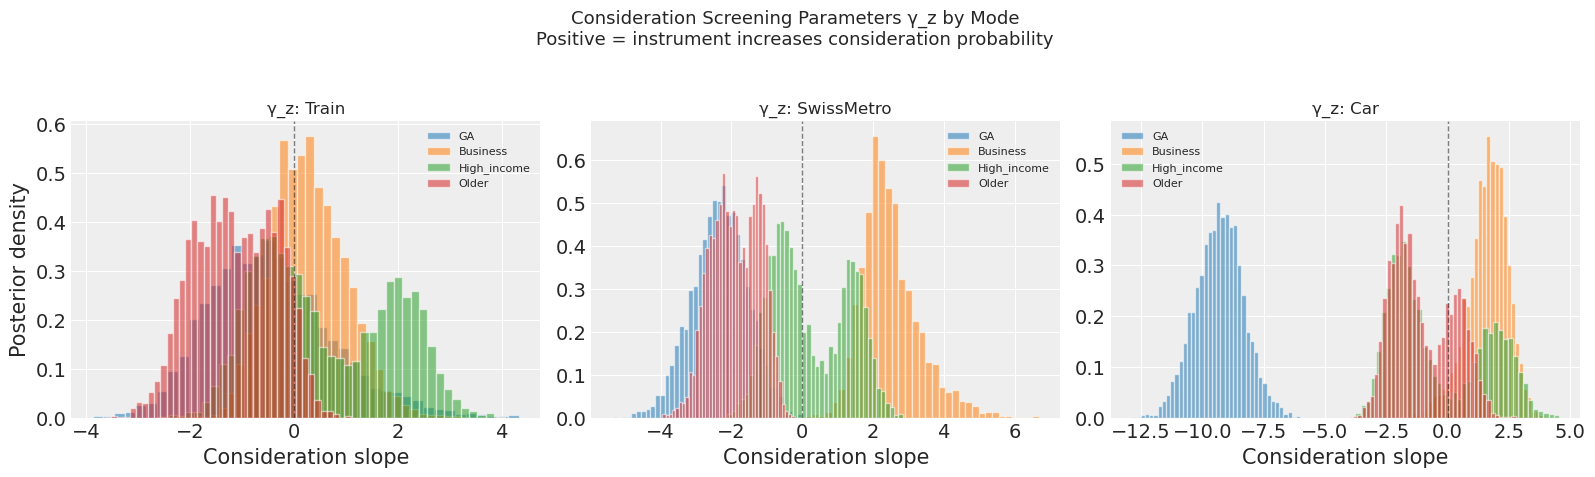

/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/4072542000.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


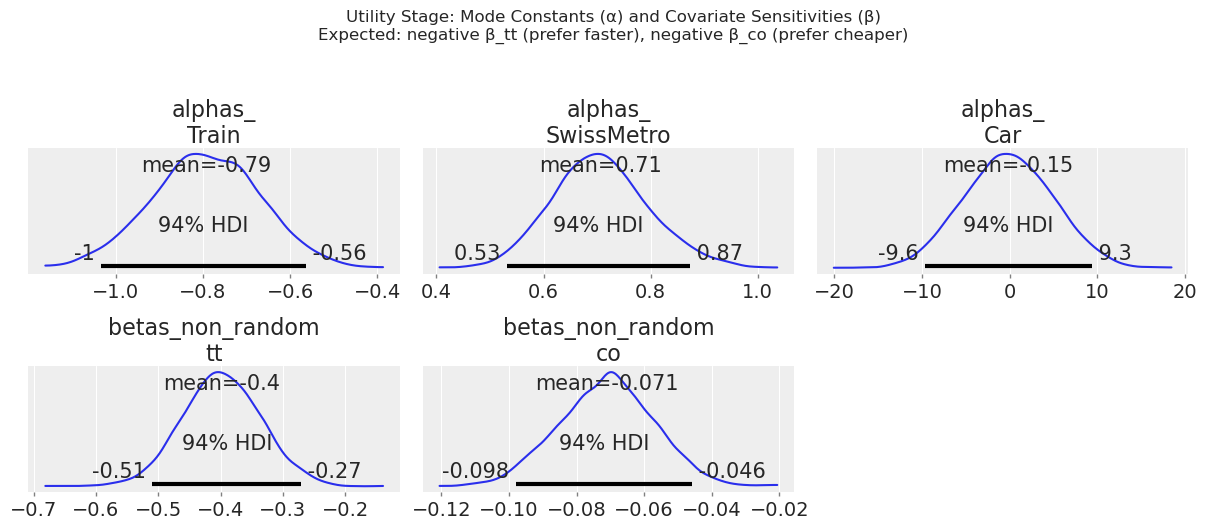

In [16]:
# ---- Consideration parameters: gamma_z by mode (4 instruments each) ----
# gamma_z has dims (alts, z_instruments) → each mode gets 4 slopes
alt_names = list(idata_vanilla.posterior.coords["alts"].values)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for j, (ax, mode) in enumerate(zip(axes, alt_names, strict=True)):
    gamma_post = idata_vanilla.posterior["gamma_z"].sel(alts=mode)
    for k, z_name in enumerate(z_names):
        samples = gamma_post.sel(z_instruments=z_name).values.flatten()
        ax.hist(
            samples,
            bins=40,
            alpha=0.55,
            label=z_name,
            density=True,
            color=colors[k],
            edgecolor="white",
        )
    ax.axvline(0, color="black", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_title(f"γ_z: {mode}", fontsize=12)
    ax.set_xlabel("Consideration slope")
    if j == 0:
        ax.set_ylabel("Posterior density")
    ax.legend(fontsize=8)

plt.suptitle(
    "Consideration Screening Parameters γ_z by Mode\n"
    "Positive = instrument increases consideration probability",
    y=1.05,
    fontsize=13,
)
plt.tight_layout()
plt.show()

# ---- Utility-stage parameters ----
az.plot_posterior(
    idata_vanilla,
    var_names=["alphas_", "betas_non_random"],
    figsize=(12, 5),
)
plt.suptitle(
    "Utility Stage: Mode Constants (α) and Covariate Sensitivities (β)\n"
    "Expected: negative β_tt (prefer faster), negative β_co (prefer cheaper)",
    y=1.05,
)
plt.tight_layout()
plt.show()

GA dominates. It strongly increases consideration of Train and SwissMetro (rail pass holders have rail on their radar) and strongly decreases Car consideration (GA holders are rail-embedded). Business and Older show more diffuse effects, suggesting weaker screening. High_income effects are moderate and mode-dependent.

Note the scale. GA slopes run ±5 to ±10; the utility-stage coefficients below are much smaller. For this population, *who considers what* matters at least as much as *how they evaluate it*.

/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/1422643233.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


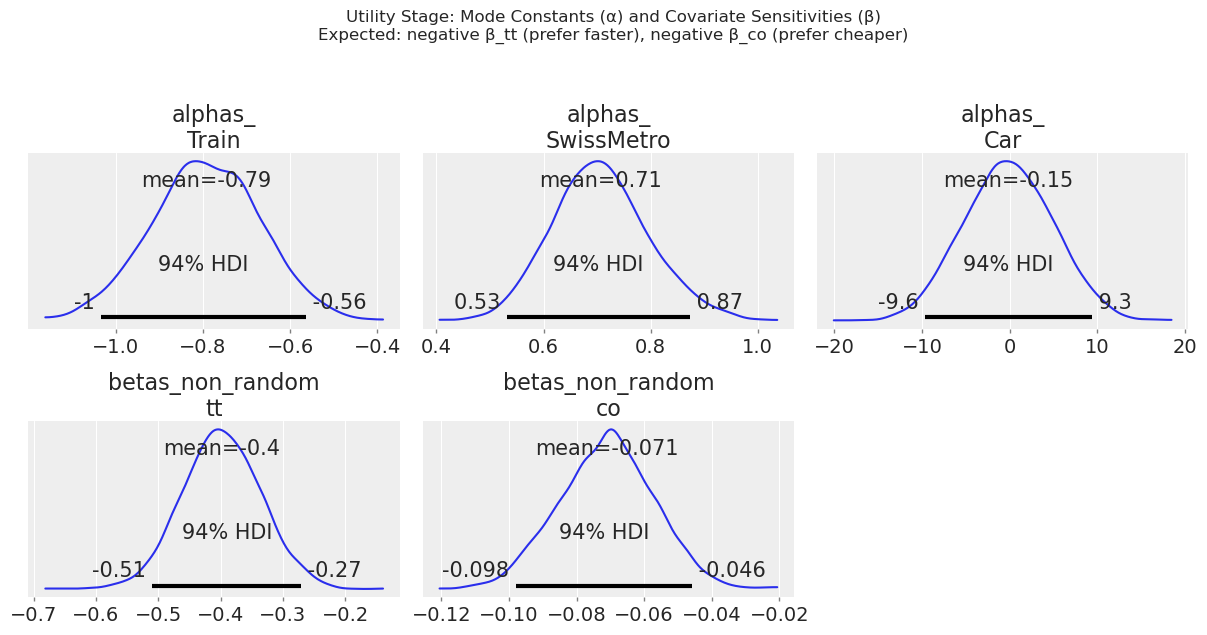

In [17]:
# ---- Utility-stage parameters ----
az.plot_posterior(
    idata_vanilla,
    var_names=["alphas_", "betas_non_random"],
    figsize=(12, 6),
)
plt.suptitle(
    "Utility Stage: Mode Constants (α) and Covariate Sensitivities (β)\n"
    "Expected: negative β_tt (prefer faster), negative β_co (prefer cheaper)",
    y=1.05,
)
plt.tight_layout()
plt.show()

The utility-stage parameters behave as expected. Both travel time and cost coefficients are negative: people prefer faster and cheaper options. The mode constants capture baseline preference after accounting for time and cost. These are the "rational evaluation" parameters, operating conditional on consideration.

## Model 2: Consideration Set Logit with Random Effects on Travel Time

We now allow taste heterogeneity in time sensitivity. Some individuals are time-sensitive business travellers; others accept longer journeys. The random coefficient $\beta^{tt}_n \sim \mathcal{N}(\mu_{tt}, \sigma_{tt}^2)$ is integrated out in the marginal likelihood:

$$P(y_n = j) = \int \frac{\pi_{nj} \cdot \exp(V_{nj}(\beta^{tt}_n))}{\sum_k \pi_{nk} \cdot \exp(V_{nk}(\beta^{tt}_n))} \, \phi(\beta^{tt}_n \mid \mu_{tt}, \sigma_{tt}) \, d\beta^{tt}_n$$

MCMC draws individual-level $\beta^{tt}_n$ values, computing this integral through sampling.

In [18]:
# Travel time is now a random coefficient (third part of formula after ||)
# Cost remains fixed
utility_equations_random = [
    "Train ~ train_tt + train_co | | train_tt",
    "SwissMetro ~ sm_tt + sm_co | | sm_tt",
    "Car ~ car_tt + car_co | | car_tt",
]

model_random = ConsiderationSetMixedLogit(
    choice_df=df_sub,
    utility_equations=utility_equations_random,
    depvar="choice",
    covariates=["tt", "co"],
    consideration_instruments={
        "Z_tilde": Z_tilde,
        "z_instrument_names": z_names,
    },
    consideration_intercept=False,
    random_consideration=False,
    group_id="ID",
    non_centered=True,  # better mixing for hierarchical models
)

model_random.build_model()
print("Model 2 (random time) free RVs:")
print([v.name for v in model_random.model.free_RVs])

Model 2 (random time) free RVs:
['alphas_', 'betas_non_random', 'mu_random', 'sigma_random', 'z_random_group', 'gamma_z']


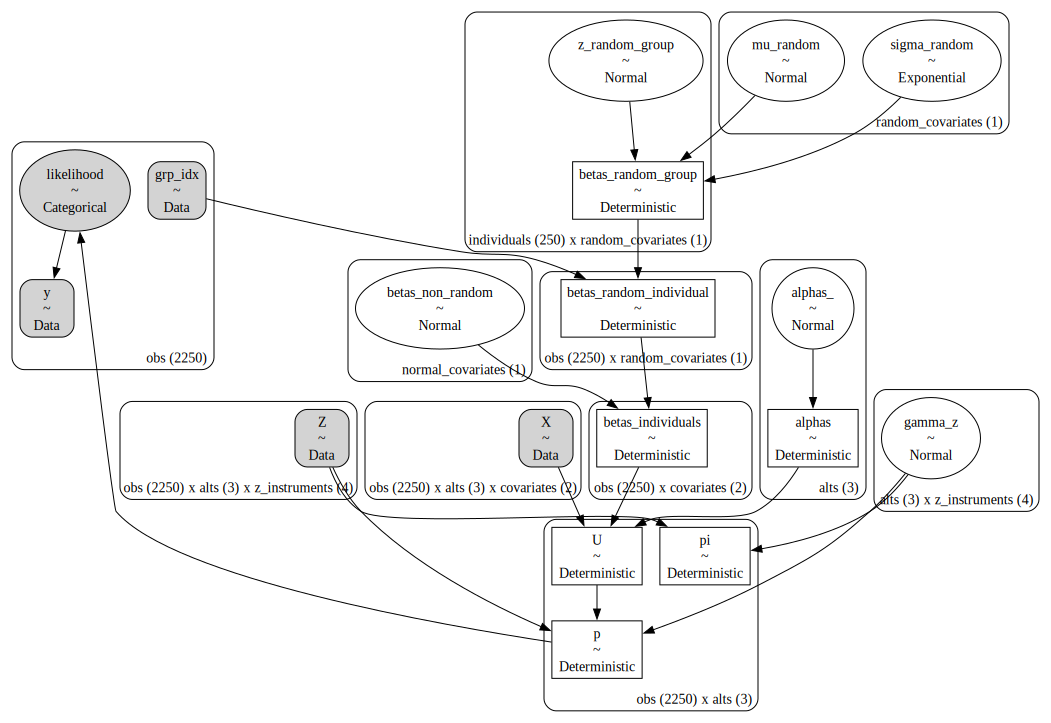

In [19]:
pm.model_to_graphviz(model_random.model)

In [20]:
idata_random = model_random.fit(
    target_accept=0.95,
    draws=500,
    tune=500,
    chains=4,
    idata_kwargs={"log_likelihood": True},
    random_seed=SEED,
)

# Generate posterior predictive (needed for baseline market shares later)
model_random.sample_posterior_predictive()

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [likelihood]


Output()

Inference data with groups:
	> posterior_predictive
	> observed_data
	> constant_data

In [21]:
var_names_random = [
    "alphas_",
    "betas_non_random",
    "mu_random",
    "sigma_random",
    "gamma_z",
]
az.summary(idata_random, var_names=var_names_random, round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alphas_[Train],-0.956,0.152,-1.256,-0.672,0.010,0.005,259.465,342.191,1.016
alphas_[SwissMetro],0.064,0.119,-0.176,0.278,0.003,0.003,1210.475,1274.552,1.003
alphas_[Car],0.076,5.003,-9.154,9.972,0.099,0.117,2568.109,1307.424,1.002
betas_non_random[co],-0.092,0.018,-0.125,-0.059,0.001,0.000,915.700,1223.788,1.004
mu_random[tt],-1.565,0.218,-1.946,-1.147,0.012,0.005,318.178,764.545,1.018
sigma_random[tt],2.996,0.231,2.552,3.393,0.010,0.005,528.221,1016.247,1.007
"gamma_z[Train, GA]",0.457,1.025,-1.338,2.402,0.047,0.036,478.458,832.475,1.008
"gamma_z[Train, Business]",0.067,0.931,-1.732,1.623,0.049,0.018,361.679,734.567,1.010
"gamma_z[Train, High_income]",2.077,0.937,-0.022,3.539,0.084,0.070,200.058,199.973,1.021
"gamma_z[Train, Older]",-0.480,0.626,-1.866,0.603,0.056,0.049,190.840,109.141,1.021


/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/1248999526.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


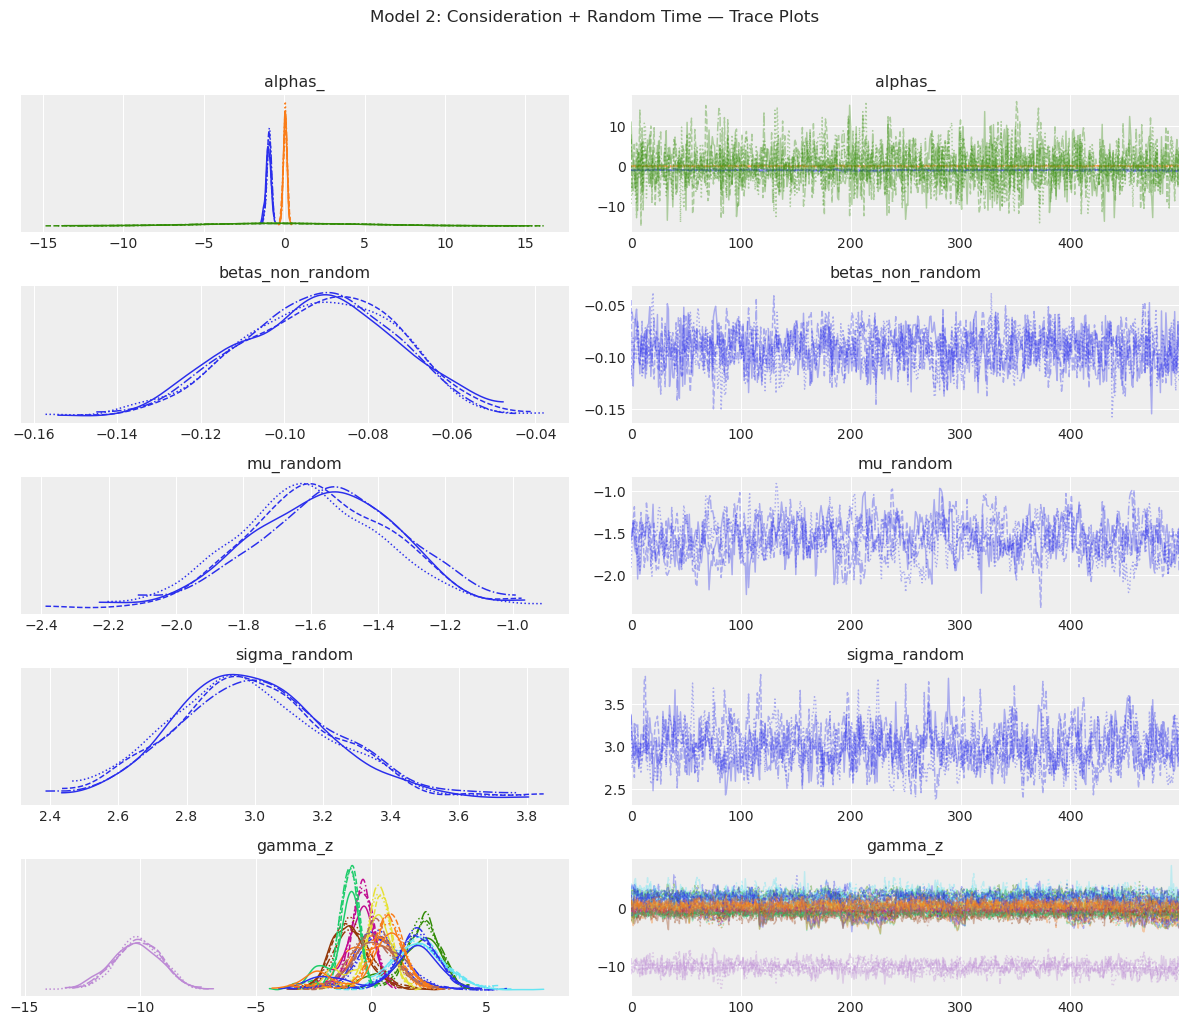

In [22]:
axes = az.plot_trace(idata_random, var_names=var_names_random, compact=True)
plt.suptitle("Model 2: Consideration + Random Time — Trace Plots", y=1.02)
plt.tight_layout()
plt.show()

### Individual-Level Heterogeneity in Time Sensitivity

The random coefficient on travel time captures taste heterogeneity. Below we plot the population distribution of individual-level time coefficients.

/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/3154690389.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


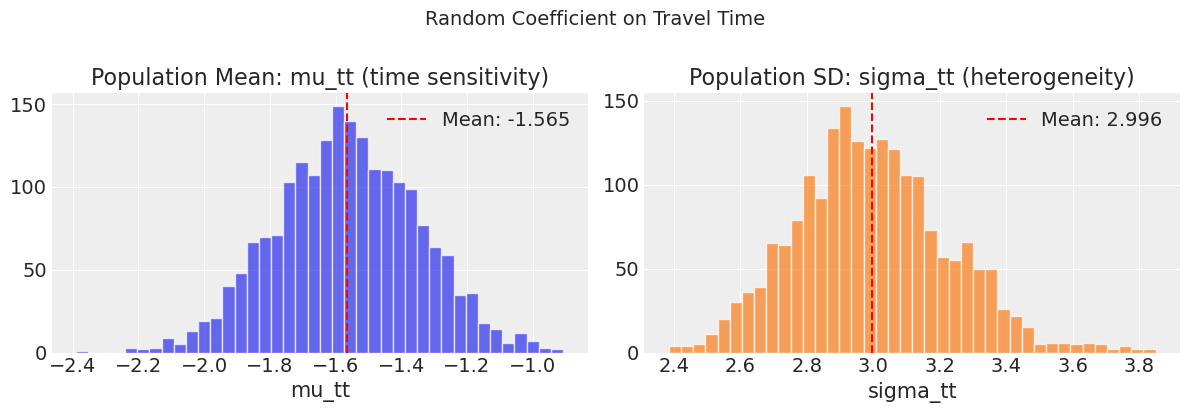

In [23]:
# Plot the population distribution of random time coefficient
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Population-level parameters
mu_tt = idata_random.posterior["mu_random"].sel(random_covariates="tt").values.flatten()
sigma_tt = (
    idata_random.posterior["sigma_random"].sel(random_covariates="tt").values.flatten()
)

axes[0].hist(mu_tt, bins=40, alpha=0.7, edgecolor="white")
axes[0].set_title("Population Mean: mu_tt (time sensitivity)")
axes[0].set_xlabel("mu_tt")
axes[0].axvline(
    mu_tt.mean(), color="red", linestyle="--", label=f"Mean: {mu_tt.mean():.3f}"
)
axes[0].legend()

axes[1].hist(sigma_tt, bins=40, alpha=0.7, edgecolor="white", color="C1")
axes[1].set_title("Population SD: sigma_tt (heterogeneity)")
axes[1].set_xlabel("sigma_tt")
axes[1].axvline(
    sigma_tt.mean(), color="red", linestyle="--", label=f"Mean: {sigma_tt.mean():.3f}"
)
axes[1].legend()

plt.suptitle("Random Coefficient on Travel Time", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Model Comparison

We compare the two models using Leave-One-Out Cross-Validation. If genuine taste heterogeneity exists, the random-effects model should fit better.

In [24]:
comparison = az.compare(
    {
        "M1: Vanilla Consideration": idata_vanilla,
        "M2: Random Time + Consideration": idata_random,
    },
    ic="loo",
)
comparison

/Users/nathanielforde/mambaforge/envs/pymc-marketing-dev/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
M2: Random Time + Consideration,0,-1481.899265,150.071481,0.00000,1.000000e+00,30.977436,0.000000,True,log
M1: Vanilla Consideration,1,-1914.435136,21.481675,432.53587,1.911921e-09,27.523953,24.167641,False,log


/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/966928058.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


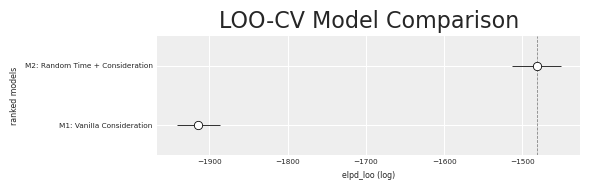

In [25]:
az.plot_compare(comparison)
plt.title("LOO-CV Model Comparison")
plt.tight_layout()
plt.show()

## Comparing Consideration Parameters Across Models

Twelve consideration slopes, shown as M1 (blue) versus M2 (orange). Most are stable. Look at **High_income × Car** (bottom row, third column).

/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/3552448333.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


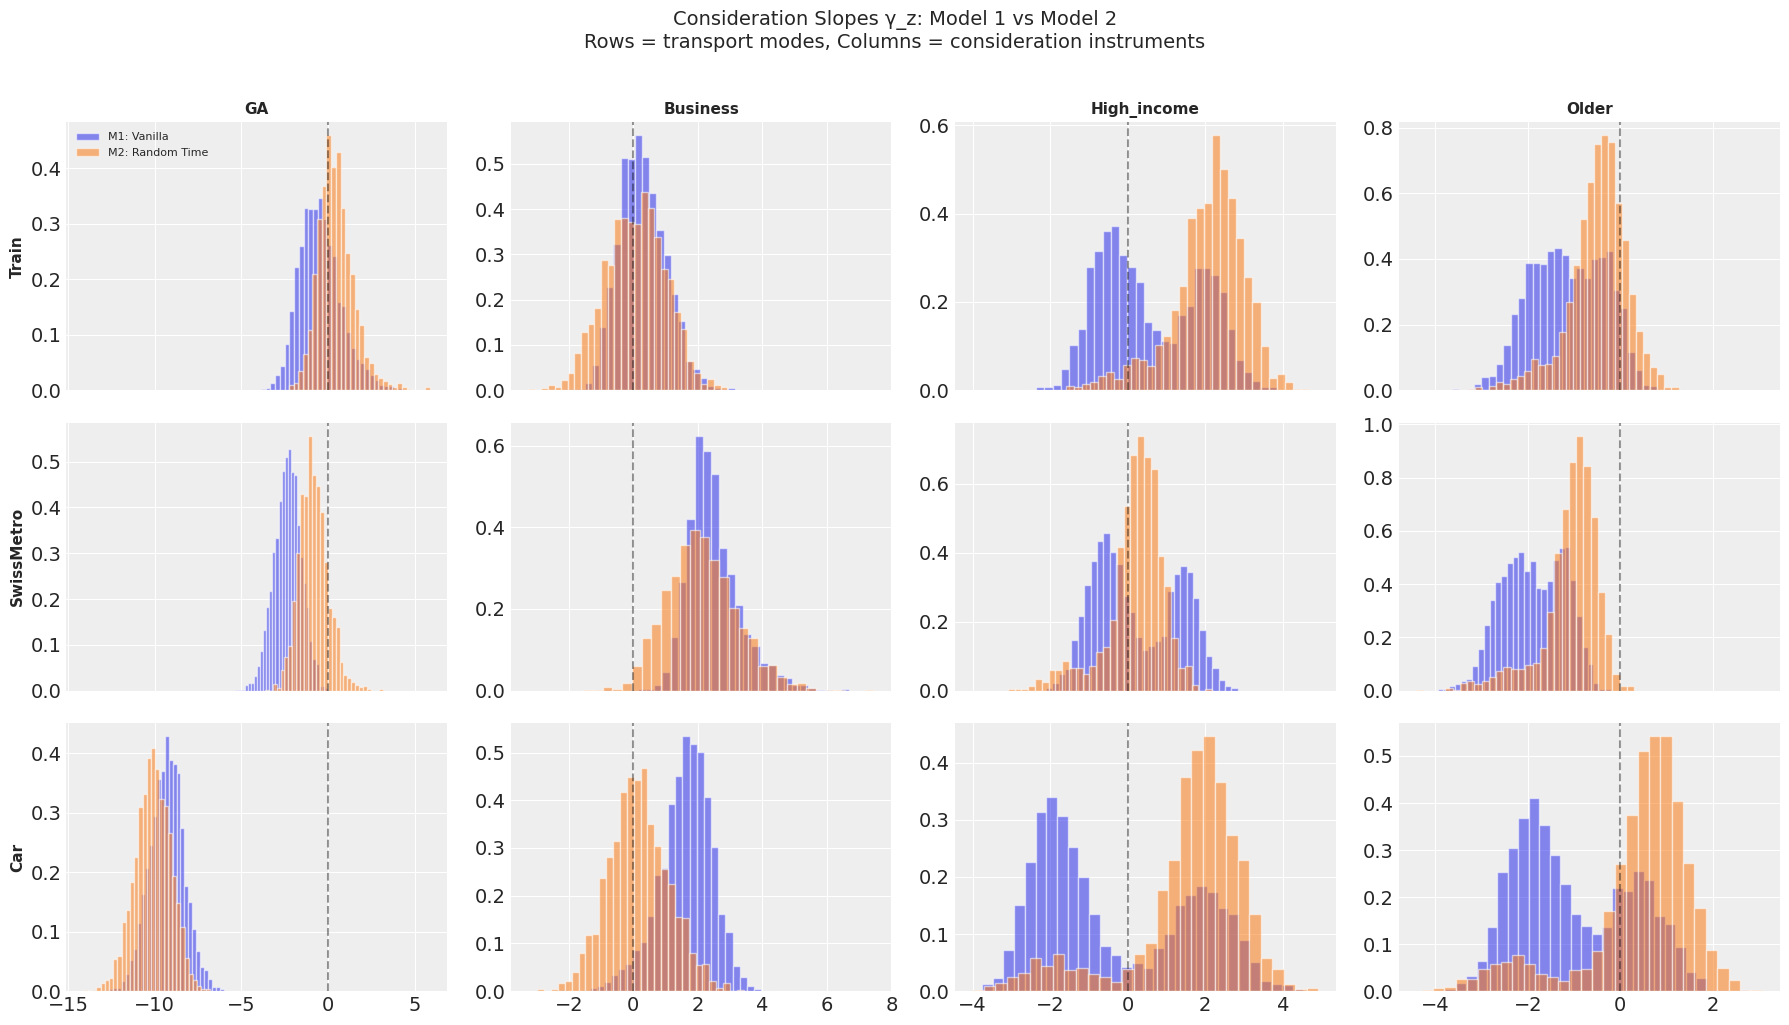

In [26]:
# Compare gamma_z (consideration slopes) between models — 4 instruments per mode
fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex="col")

for j, mode in enumerate(alt_names):
    gz_vanilla = idata_vanilla.posterior["gamma_z"].sel(alts=mode)
    gz_random = idata_random.posterior["gamma_z"].sel(alts=mode)

    for k, z_name in enumerate(z_names):
        ax = axes[j, k]
        v_samples = gz_vanilla.sel(z_instruments=z_name).values.flatten()
        r_samples = gz_random.sel(z_instruments=z_name).values.flatten()
        ax.hist(
            v_samples,
            bins=30,
            alpha=0.55,
            label="M1: Vanilla",
            density=True,
            color="C0",
            edgecolor="white",
        )
        ax.hist(
            r_samples,
            bins=30,
            alpha=0.55,
            label="M2: Random Time",
            density=True,
            color="C1",
            edgecolor="white",
        )
        ax.axvline(0, color="black", linestyle="--", alpha=0.4)
        if j == 0:
            ax.set_title(z_name, fontsize=11, fontweight="bold")
        if k == 0:
            ax.set_ylabel(mode, fontsize=11, fontweight="bold")
        if j == 0 and k == 0:
            ax.legend(fontsize=8)

plt.suptitle(
    "Consideration Slopes γ_z: Model 1 vs Model 2\n"
    "Rows = transport modes, Columns = consideration instruments",
    y=1.02,
    fontsize=14,
)
plt.tight_layout()
plt.show()

### The High_income × Car Sign Flip

The striking result is in the bottom row, third column. In M1, the posterior is mostly positive: high income increases car consideration. Intuitive enough, since wealthier people are more likely to own cars. In M2, the sign flips negative.

The explanation is confounding between time sensitivity and income. High-income individuals tend to have a higher value of time. In M1, with fixed time coefficients, the model cannot capture this, so `gamma_z[Car, High_income]` absorbs the effect. High earners *appear* to consider Car more when they are really responding more strongly to Car's door-to-door speed advantage.

M2 introduces random coefficients on travel time. Individual-level time sensitivity is now captured by $\beta^{tt}_n$. The consideration slope is freed to reflect the *residual* income effect: conditional on time preferences, high-income Swiss travellers are less likely to consider Car, perhaps because they are the urban professionals who hold GA passes and default to rail.

The lesson is plain. Consideration parameters are only identifiable up to the quality of the utility specification. A misspecified utility stage does not just produce wrong utility estimates. It contaminates the consideration story.

## Counterfactual: What if Everyone Held a GA Pass?

The consideration set model lets us simulate interventions that widen the streetlamp rather than change what's underneath it. Here we give every traveller a GA pass, shifting the GA column of `Z_tilde` to its maximum.

### A necessary caveat

This counterfactual is a stress test of the model, not a policy forecast. People who lack a GA pass often have good reasons: they live far from rail, travel infrequently, or prefer driving. GA ownership is endogenous to lifestyle and geography, not randomly assigned. Giving everyone a pass in the model changes where the drunk looks, but cannot change where the keys are.

GA is really a proxy for rail-embeddedness. Extrapolating to universal ownership pushes far beyond the support of the data. Read the results below as "what the model thinks would happen," not "what would happen."

The sensitivity of `gamma_z` to utility-stage specification reinforces this caution. The sign flip on High_income × Car shows that consideration parameters absorb different things depending on what the utility stage captures. A counterfactual built on M1's estimates would tell a different story than one built on M2's.

In [27]:
# Counterfactual: universal GA — everyone holds a rail pass
# The GA instrument is the first column (index 0) in Z_tilde[:, :, 0]
# Under the counterfactual, GA = 1 for everyone, so Z_tilde_GA = 1 - mean(GA)
Z_tilde_cf = Z_tilde.copy()
ga_shift = 1.0 - Z_means[0]  # shift from mean-centred to "everyone has GA"
Z_tilde_cf[:, :, 0] = ga_shift  # set GA instrument to counterfactual for all modes

print(f"Baseline GA rate: {Z_means[0]:.1%}")
print("Counterfactual: universal GA (100%)")
print(f"GA Z_tilde shifts from mean 0 to {ga_shift:.3f}")

# Apply intervention using Model 2 (random time)
idata_cf = model_random.apply_intervention(
    new_choice_df=df_sub,
    new_consideration_instruments={
        "Z_tilde": Z_tilde_cf,
        "z_instrument_names": z_names,
    },
)

Sampling: [likelihood]


Output()

Baseline GA rate: 15.6%
Counterfactual: universal GA (100%)
GA Z_tilde shifts from mean 0 to 0.844


In [28]:
# Compare market shares: baseline vs counterfactual
# model_random.idata has posterior_predictive from sample_posterior_predictive()
p_baseline = (
    model_random.idata.posterior_predictive["p"].mean(dim=["chain", "draw"]).values
)
p_cf = idata_cf.posterior_predictive["p"].mean(dim=["chain", "draw"]).values

share_baseline = p_baseline.mean(axis=0)
share_cf = p_cf.mean(axis=0)

share_df = pd.DataFrame(
    {
        "Alternative": alt_names,
        "Baseline Share": share_baseline,
        "Counterfactual Share": share_cf,
        "Change": share_cf - share_baseline,
        "% Change": 100 * (share_cf - share_baseline) / share_baseline,
    }
).round(4)

print("Market Share Impact of Universal GA Pass:")
share_df

Market Share Impact of Universal GA Pass:


,Alternative,Baseline Share,Counterfactual Share,Change,% Change
0,Train,0.1511,0.2755,0.1244,82.3752
1,SwissMetro,0.5576,0.7182,0.1605,28.7886
2,Car,0.2913,0.0063,-0.2850,-97.8343


/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_25231/336134915.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


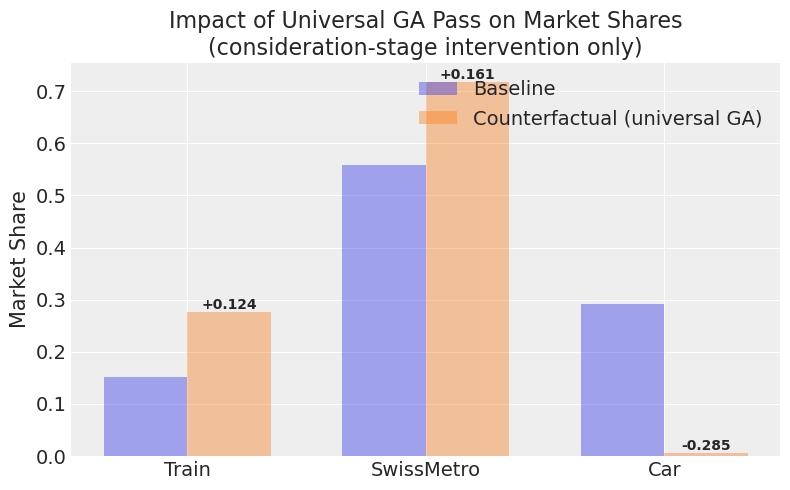

In [29]:
# Visualise the share change
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(alt_names))
width = 0.35
bars1 = ax.bar(x - width / 2, share_baseline, width, label="Baseline", alpha=0.4)
bars2 = ax.bar(
    x + width / 2,
    share_cf,
    width,
    label="Counterfactual (universal GA)",
    alpha=0.4,
)
ax.set_xticks(x)
ax.set_xticklabels(alt_names)
ax.set_ylabel("Market Share")
ax.set_title(
    "Impact of Universal GA Pass on Market Shares\n"
    "(consideration-stage intervention only)"
)
ax.legend()

# Add change annotations
for i, (b, cf) in enumerate(zip(share_baseline, share_cf, strict=True)):
    change = cf - b
    ax.annotate(
        f"{change:+.3f}",
        xy=(x[i] + width / 2, cf),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

The near-zero car share is implausible. People own cars and use them for reasons unrelated to lacking a rail pass. But the value of the counterfactual is in the mechanism, not the numbers.

In settings where the exclusion restriction is more defensible, this framework quantifies something important. Consider hiring. Race or gender may affect whether a candidate is *seen* without affecting their productivity conditional on evaluation. A consideration set model applied to hiring data would decompose how much of the outcome is driven by the narrowness of the consideration set versus genuine preference. The counterfactual probe would then quantify the cost of bias at the screening stage, where its effects are most dramatic and most actionable.

The Swiss Metro example clouds the picture because GA plausibly plays two roles: it drives consideration *and* proxies for utility (rail-embedded lifestyles correlate with rail-favourable preferences). In an ideal application, the screening instruments would be independent of the utility calculation but meaningful for the consideration calculation.

## Summary

Consideration dominates the Swiss Metro choice setting. The `gamma_z` slopes, especially for GA, are large relative to utility parameters. Who notices what matters at least as much as how they evaluate it.

The comparison between models sharpens this conclusion and complicates it. Adding random effects on travel time (Model 2) flips the sign on High_income × Car, showing that consideration parameters absorb whatever the utility stage fails to capture. Both stages need proper specification, and no single model's consideration estimates should be taken at face value without comparison.

The counterfactual exercise reinforces the point. The universal-GA scenario is deliberately extreme and produces implausible predictions. Its value is not in the numbers but in revealing the model's structure: how much screening matters, and where the instruments are doing real work versus proxying for unmodeled preference heterogeneity. In domains with cleaner exclusion restrictions, such as hiring, the same framework would produce more credible counterfactuals and more actionable diagnoses.

The `ConsiderationSetMixedLogit` class extends the existing `MixedLogit` with a consideration stage, supports multiple instruments per alternative, and provides `apply_intervention` for counterfactual analysis.

In [30]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing

Last updated: Wed Mar 25 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.8.0

pymc_marketing: 0.19.0

matplotlib    : 3.10.8
arviz         : 0.23.0
numpy         : 2.3.5
pymc_marketing: 0.19.0
pandas        : 2.3.3
pymc          : 5.28.2

Watermark: 2.5.0

